In [1]:
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
import cv2

**Convolution Mathematical Definition:**

$$\text{Output}[i,j] = \sum_m \sum_n \text{Input}[i+m, j+n] \times \text{Filter}[m,n]$$

### Sobel Operator

- Detects edges by computing gradient approximations

In [2]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

In [3]:
img = np.zeros((100, 100))
img[30:70, 30:70] = 1

In [4]:
# Apply Sobel filters
edges_x = ndimage.convolve(img, sobel_x)
edges_y = ndimage.convolve(img, sobel_y)

edges_magnitude = np.sqrt(edges_x**2 + edges_y**2)

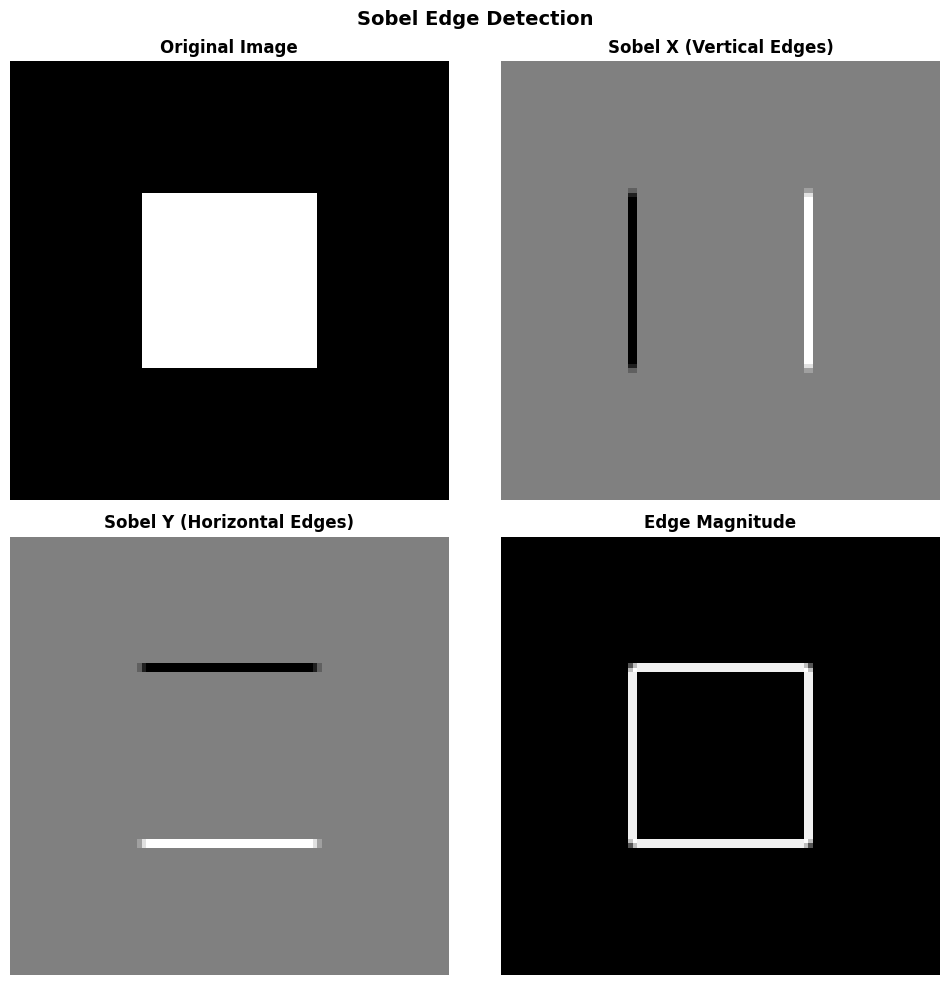

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(edges_x, cmap='gray')
axes[0, 1].set_title('Sobel X (Vertical Edges)', fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(edges_y, cmap='gray')
axes[1, 0].set_title('Sobel Y (Horizontal Edges)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(edges_magnitude, cmap='gray')
axes[1, 1].set_title('Edge Magnitude', fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle('Sobel Edge Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Canny Edge Detector

- Multi-stage algorithm for optimal edge detection

In [6]:
image = cv2.imread('C:/Users/User/Pictures/wallpapers/rt.jpg')

In [7]:
# Canny edge detection
edges = cv2.Canny(image, threshold1=50, threshold2=150)

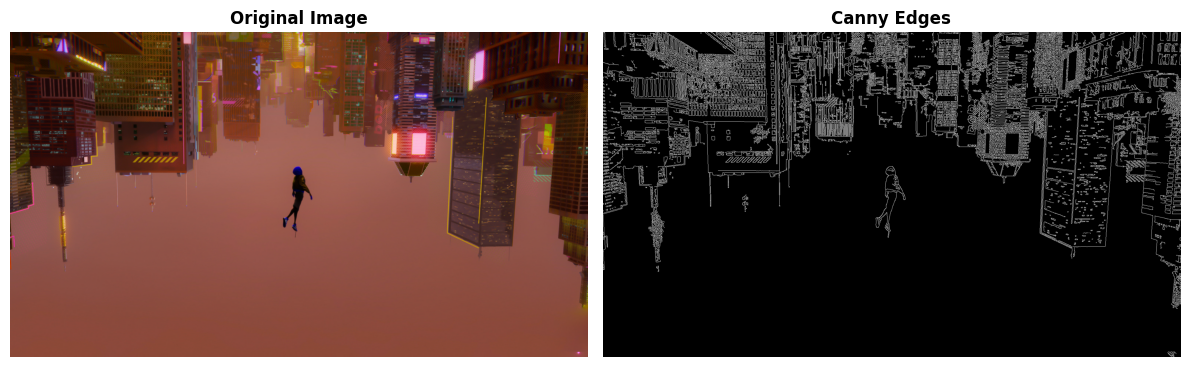

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edges', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Prewitt Operator

- Similar to Sobel but with different weights

In [9]:
prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])
prewitt_y = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
])

In [16]:
edges_x_prewitt = ndimage.convolve(img, prewitt_x)
edges_y_prewitt = ndimage.convolve(img, prewitt_y)

edges_prewitt = np.sqrt(edges_x_prewitt**2 + edges_y_prewitt**2)

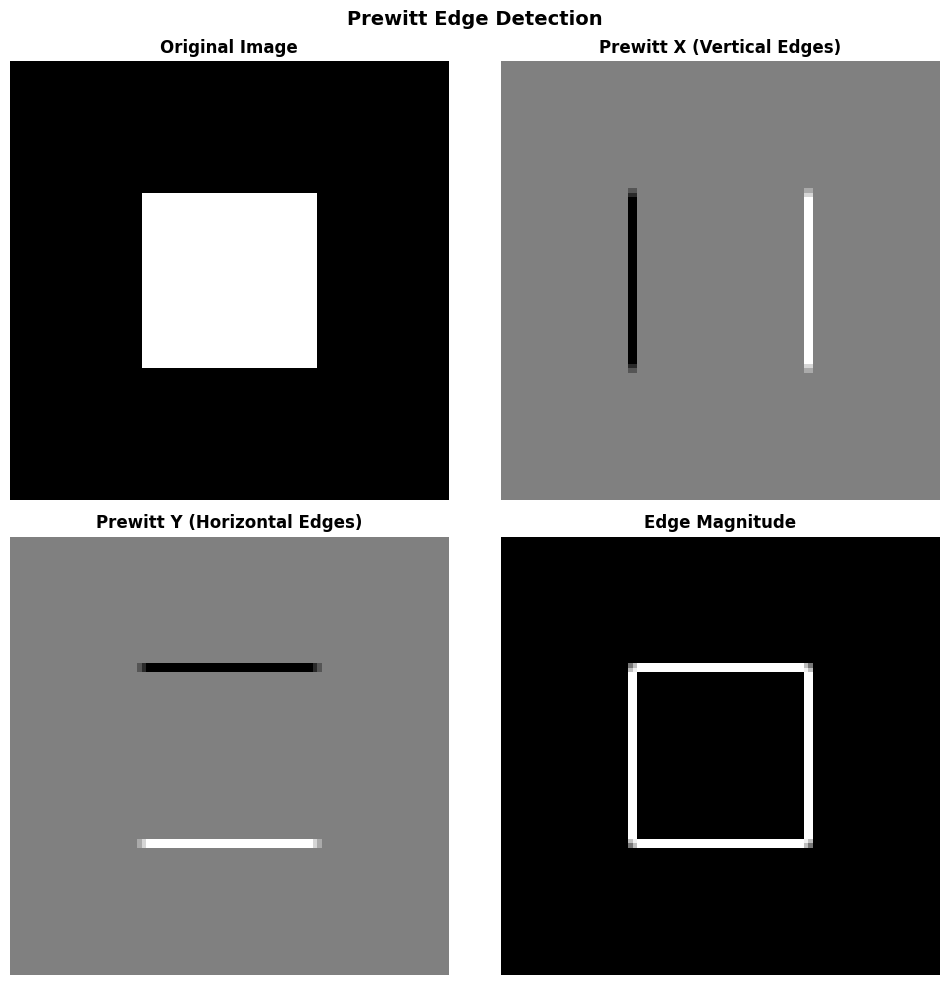

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(edges_x_prewitt, cmap='gray')
axes[0, 1].set_title('Prewitt X (Vertical Edges)', fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(edges_y_prewitt, cmap='gray')
axes[1, 0].set_title('Prewitt Y (Horizontal Edges)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(edges_prewitt, cmap='gray')
axes[1, 1].set_title('Edge Magnitude', fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle('Prewitt Edge Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  using OpenCV

In [17]:
# Load image
img = cv2.imread('C:/Users/User/Pictures/wallpapers/rt.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

1. Sobel edge detection

In [18]:
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

sobel_combined = np.sqrt(sobelx**2 + sobely**2)

2. Laplacian edge detection

In [19]:
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

3. Canny edge detection

In [20]:
canny = cv2.Canny(gray, 50, 150)

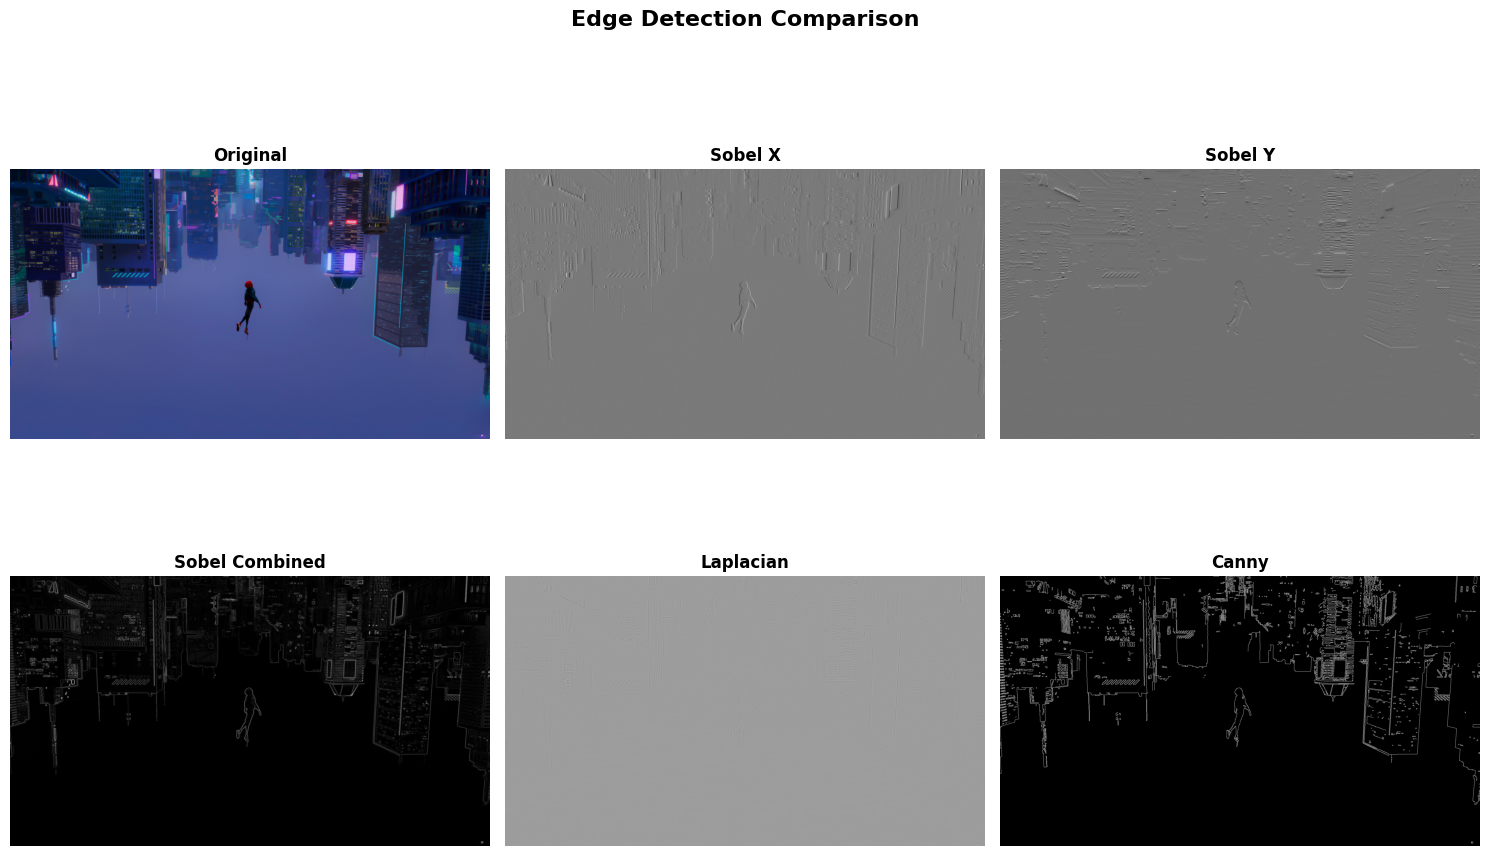

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(sobelx, cmap='gray')
axes[0, 1].set_title('Sobel X', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(sobely, cmap='gray')
axes[0, 2].set_title('Sobel Y', fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(sobel_combined, cmap='gray')
axes[1, 0].set_title('Sobel Combined', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(laplacian, cmap='gray')
axes[1, 1].set_title('Laplacian', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(canny, cmap='gray')
axes[1, 2].set_title('Canny', fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Edge Detection Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()